### 0. Load packages

In [1]:
# load default packages
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# load random forest model & helper functions
from random_forest_classify import *
from utils import *

In [2]:
random.seed(1)

### 1. Weather dataset

In [7]:
# load data
df = pd.read_csv("data/tennis.txt")
df = df.drop(['Day'], axis = 1)

In [67]:
%%timeit

cls = Random_Forest_Classification(max_depth_ = 3, min_split_val_=2)
cls.fit(df, 30)
preds = cls.predict(df)

262 ms ± 31.3 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


In [68]:
%%timeit

cls = Random_Forest_Classification(max_depth_ = 3, min_split_val_=2)
cls.fit(df, 1000)
preds = cls.predict(df)

3.43 s ± 203 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


In [69]:
cls = Random_Forest_Classification(max_depth_ = 3, min_split_val_=2)
cls.fit(df, 30)
accuracy(cls.predict(df), df['Play'])

1.0

In [70]:
eva_list = []
for i in range(1,101,1):
    cls = Random_Forest_Classification(max_depth_ = 3, min_split_val_=2)
    cls.fit(df, i)

    pred = cls.predict(df)
    acc = accuracy(pred, df['Play']) 

    pred_oob = cls.predict_all_oob_points(df)
    oob_error = 1 - accuracy(pred_oob, df.loc[pred_oob.index]['Play']) 

    eva_list.append([acc, oob_error])
df_e = pd.DataFrame(eva_list,columns=['accuracy','OOB_error_rate'])
df_e['number_of_trees'] = pd.Series(range(1,101,1))

In [71]:
df_e.sort_values(['accuracy', 'OOB_error_rate'], ascending = [False, True]).head(10)

,accuracy,OOB_error_rate,number_of_trees
0,1.0,0.0,1
7,1.0,0.0,8
14,1.0,0.0,15
18,1.0,0.0,19
22,1.0,0.0,23
24,1.0,0.0,25
29,1.0,0.0,30
33,1.0,0.0,34
34,1.0,0.0,35
40,1.0,0.0,41


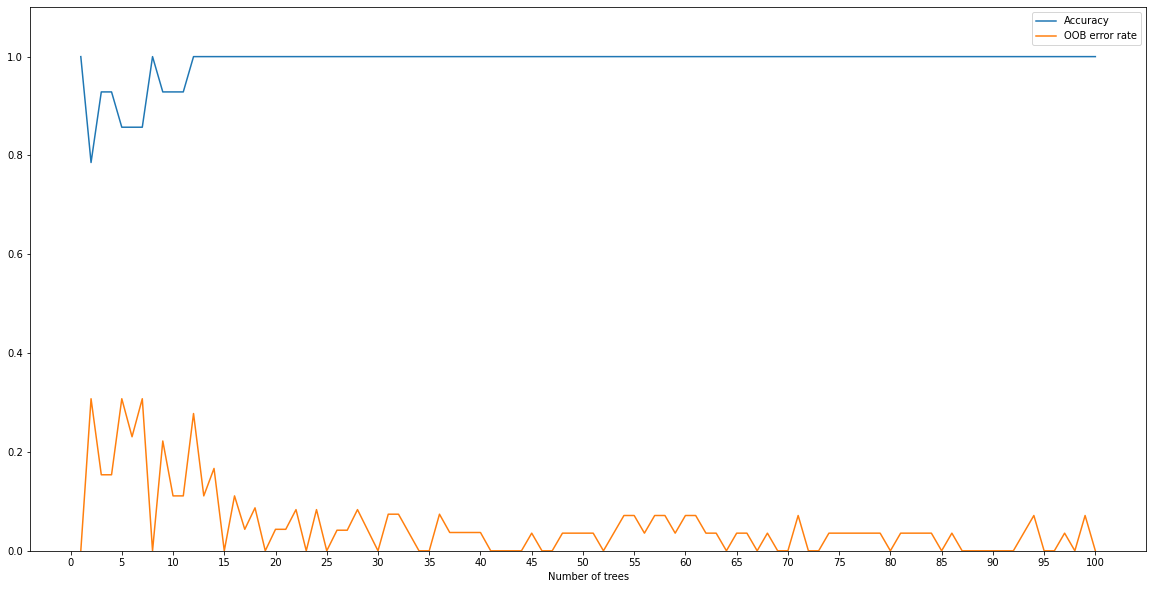

In [80]:
fig, ax = plt.subplots(figsize=(20, 10))
df_e.plot('number_of_trees', 'accuracy', ax= ax, label = 'Accuracy')
df_e.plot('number_of_trees', 'OOB_error_rate', ax= ax, label = 'OOB error rate')
ax.set(ylim=(0,1.1), xticks = range(0,101,5), xlabel='Number of trees')
t = df_e[df_e['accuracy']==1]['number_of_trees'].to_list()[0]
plt.show()

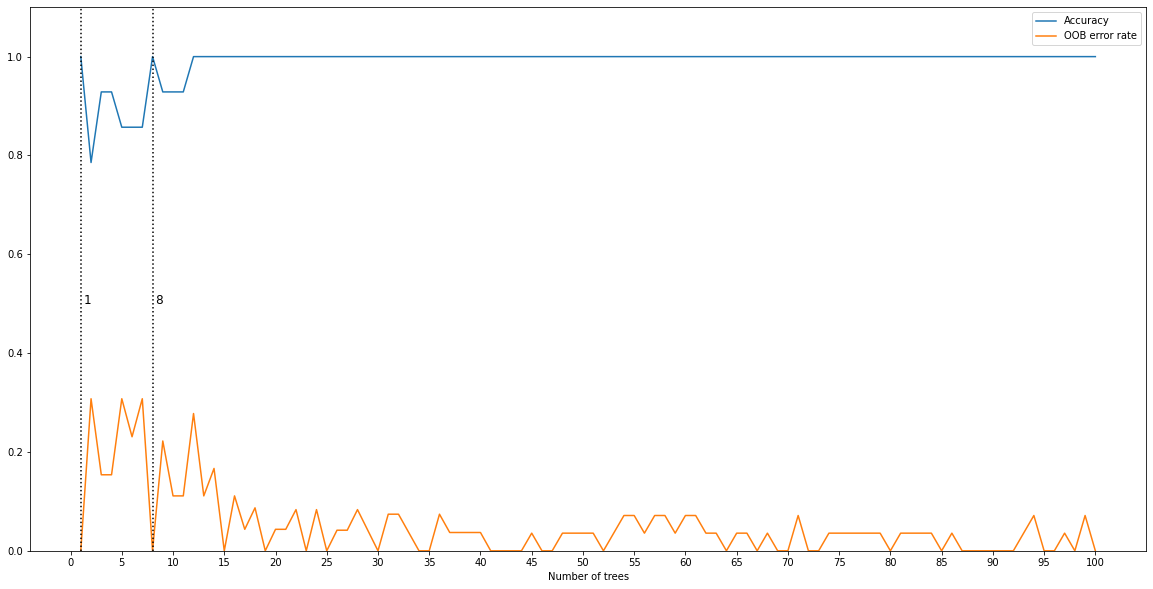

In [76]:
fig, ax = plt.subplots(figsize=(20, 10))
df_e.plot('number_of_trees', 'accuracy', ax= ax, label = 'Accuracy')
df_e.plot('number_of_trees', 'OOB_error_rate', ax= ax, label = 'OOB error rate')
ax.set(ylim=(0,1.1), xticks = range(0,101,5), xlabel='Number of trees')
t = df_e[df_e['accuracy']==1]['number_of_trees'].to_list()[0]
ax.axvline(x=t, linestyle=':', color = 'black')
plt.text(t+0.3, 0.5, t, fontsize = 12)
# ax.axvline(x=5, linestyle=':', color = 'black')
# plt.text(5+0.3, 0.5, 5, fontsize = 12)
ax.axvline(x=8, linestyle=':', color = 'black')
plt.text(8+0.3, 0.5, 8, fontsize = 12)
# ax.get_legend().remove()
# for i, v in zip(df_e2['min_split'], round(df_e2['mean_acc'], 3)):
#     ax.text(i, v+.02, f"{v}", fontsize=8, ha="center")
plt.show()

### 2. Car evaluation dataset

In [44]:
# load data
df2 = pd.read_csv("data/car_evaluation.csv", header = None)
df2.columns =['buying', 'maint', 'doors', 'persons', 'lug_boot', 'safety', 'class']

In [45]:
# convert to 2 classes
df2['class'] = df2['class'].apply(lambda x: "0" if x == "unacc" else "1").astype('int')

In [46]:
test, train = train_test_split(df2, 0.2, 'class')

In [66]:
# fit car dataset to decision trees
car_pred = Random_Forest_Classification(max_depth_ = 10, min_split_val_=2)
car_pred.fit(train, 40)
accuracy(car_pred.predict(test), test['class'])

0.976878612716763

In [22]:
# Confusion matrix
pd.crosstab(pd.Series(car_pred.predict(test)), pd.Series(test['class']), rownames=['Actual'], colnames=['Predicted'], margins=True)

Predicted,0,1,All
Actual,,,
0,260,11,271
1,0,75,75
All,260,86,346


In [77]:
eva_list2 = []
set_range = range(1,101,1)

p_list = []
r_list = []
F_list = []

for i in set_range:
    car_preds = Random_Forest_Classification(max_depth_= 5, min_split_val_=2)
    car_preds.fit(train, i)

    pred = car_preds.predict(test)
    acc = accuracy(pred, test['class']) 

    pred_oob = car_preds.predict_all_oob_points(test)
    oob_error = 1 - accuracy(pred_oob, test.loc[pred_oob.index]['class']) 

    

    tp = np.sum(np.logical_and(test['class'] == 1, pred == 1))
    tn = np.sum(np.logical_and(pred == 0, test['class'] == 0))
    fp = np.sum(np.logical_and(pred == 1, test['class'] == 0))
    fn = np.sum(np.logical_and(pred == 0, test['class'] == 1))

    # Precision
    p = tp/ (tp+fp) 
    # Recall
    r = tp/ (tp+fn) 
    # F-score
    # F = (2*p*r)/(p+r)
    F = (2*p*r)/(p+r)

    eva_list2.append([acc, oob_error, p, r, F])


df2_e2 = pd.DataFrame(eva_list2,columns=['accuracy','OOB_error_rate', 'precision', 'recall', 'f-score'])
df2_e2['number_of_trees'] = pd.Series(set_range)

In [78]:
df2_e2.sort_values(['accuracy', 'OOB_error_rate'], ascending = [False, True]).head(10)

,accuracy,OOB_error_rate,precision,recall,f-score,number_of_trees
99,0.965318,0.046243,0.877551,1.000000,0.934783,100
93,0.965318,0.052023,0.877551,1.000000,0.934783,94
98,0.965318,0.063584,0.877551,1.000000,0.934783,99
87,0.962428,0.052023,0.876289,0.988372,0.928962,88
92,0.962428,0.052023,0.868687,1.000000,0.929730,93
85,0.962428,0.052174,0.868687,1.000000,0.929730,86
59,0.962428,0.062315,0.876289,0.988372,0.928962,60
48,0.959538,0.042296,0.860000,1.000000,0.924731,49
64,0.959538,0.046921,0.860000,1.000000,0.924731,65
95,0.959538,0.049133,0.860000,1.000000,0.924731,96


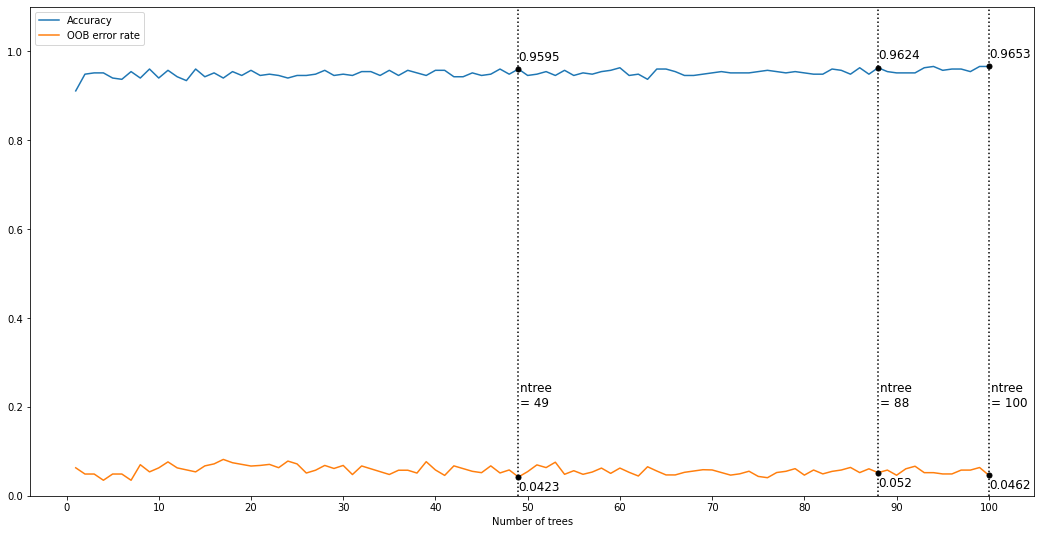

In [84]:
fig, ax = plt.subplots(figsize=(18, 18/2))
df2_e2.plot('number_of_trees', 'accuracy', ax=ax, label = 'Accuracy')
df2_e2.plot('number_of_trees', 'OOB_error_rate', ax= ax, label = 'OOB error rate')
# df2_e2.plot('number_of_trees', 'precision', ax= ax, label = 'Precision')
# df2_e2.plot('number_of_trees', 'recall', ax= ax, label = 'Recall')
# df2_e2.plot('number_of_trees', 'f-score', ax= ax, label = 'F score')
ax.set(ylim=(0,1.1), xticks = range(0,101,10), xlabel='Number of trees')

for i in [99, 87, 48]:
    ax.axvline(x=i+1, linestyle=':', color = 'black')
    plt.text(i+1.2, 0.2, 'ntree \n= ' + str(i+1), fontsize = 12)
    plt.text(i+1, df2_e2.iloc[i,0]+0.02, str(round(df2_e2.iloc[i,0], 4)), fontsize = 12)
    plt.plot(i+1, df2_e2.iloc[i,0], marker="o", markersize=5, markerfacecolor="black", markeredgecolor="black")
    plt.text(i+1, df2_e2.iloc[i,1]-0.03, str(round(df2_e2.iloc[i,1], 4)), fontsize = 12)
    plt.plot(i+1, df2_e2.iloc[i,1], marker="o", markersize=5, markerfacecolor="black", markeredgecolor="black")
plt.show()

In [86]:
eva_list2 = []
set_range = range(1,1001,20)

p_list = []
r_list = []
F_list = []

for i in set_range:
    car_preds = Random_Forest_Classification(max_depth_= 5, min_split_val_=2)
    car_preds.fit(train, i)

    pred = car_preds.predict(test)
    acc = accuracy(pred, test['class']) 

    pred_oob = car_preds.predict_all_oob_points(test)
    oob_error = 1 - accuracy(pred_oob, test.loc[pred_oob.index]['class']) 

    

    tp = np.sum(np.logical_and(test['class'] == 1, pred == 1))
    tn = np.sum(np.logical_and(pred == 0, test['class'] == 0))
    fp = np.sum(np.logical_and(pred == 1, test['class'] == 0))
    fn = np.sum(np.logical_and(pred == 0, test['class'] == 1))

    # Precision
    p = tp/ (tp+fp) 
    # Recall
    r = tp/ (tp+fn) 
    # F-score
    # F = (2*p*r)/(p+r)
    F = (2*p*r)/(p+r)

    eva_list2.append([acc, oob_error, p, r, F])


df2_e2 = pd.DataFrame(eva_list2,columns=['accuracy','OOB_error_rate', 'precision', 'recall', 'f-score'])
df2_e2['number_of_trees'] = pd.Series(set_range)

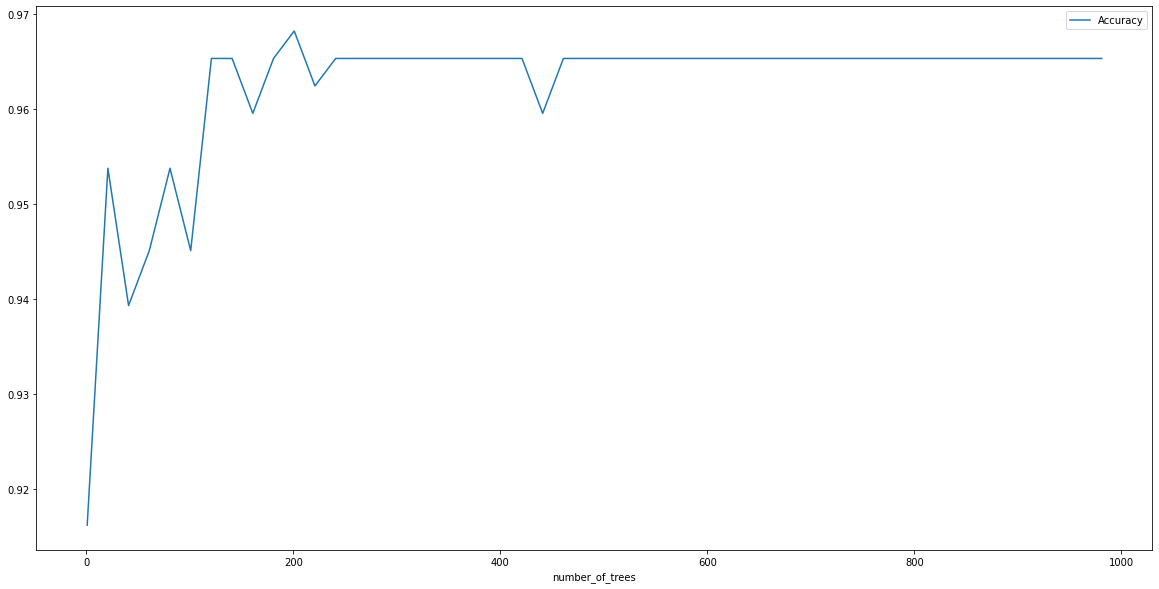

In [89]:
fig, ax = plt.subplots(figsize=(20, 10))
df2_e2.plot('number_of_trees', 'accuracy', ax=ax, label = 'Accuracy')
# df2_e2.plot('number_of_trees', 'OOB_error_rate', ax= ax, label = 'OOB error rate')
# df2_e2.plot('number_of_trees', 'precision', ax= ax, label = 'Precision')
# df2_e2.plot('number_of_trees', 'recall', ax= ax, label = 'Recall')
# df2_e2.plot('number_of_trees', 'f-score', ax= ax, label = 'F score')
# ax.set(ylim=(0,1.1), xticks = range(0,1001,100), xlabel='Number of trees')
plt.show()

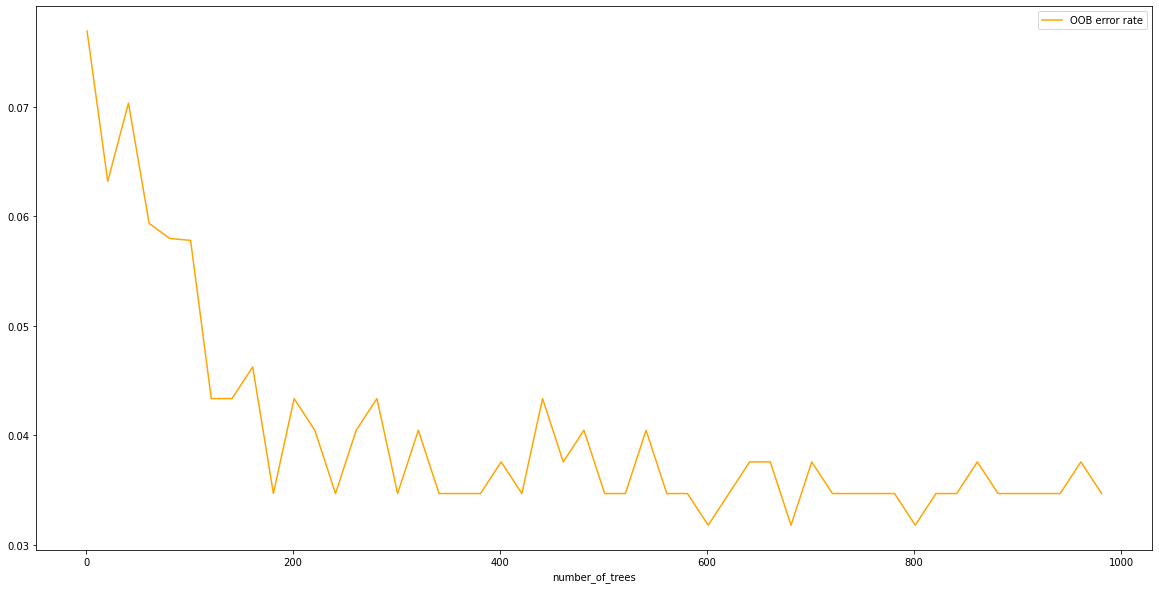

In [91]:
fig, ax = plt.subplots(figsize=(20, 10))
df2_e2.plot('number_of_trees', 'OOB_error_rate', ax= ax, label = 'OOB error rate', color = 'orange')
plt.show()